# Deep Multiclass Classification with PyTorch (GPU, Saliency, Metrics)

This notebook demonstrates a deep neural network (ANN-style classifier) for **multiclass image classification** using PyTorch.

Features:
- Uses the **CIFAR-10** dataset from `torchvision.datasets` (download handled automatically by PyTorch).
- Deep convolutional neural network designed for strong accuracy.
- Trains on **GPU** when available.
- Computes classification metrics (accuracy, precision, recall, F1, MCC, Cohen's kappa) with **bootstrap-based variance estimates**.
- Plots:
  - Training and validation loss curves.
  - ROC AUC box plot from bootstrap scores.
  - Train vs. test AUROC curves (micro-averaged).
  - AUPRC (precision–recall) curve.
  - Confusion matrix heatmap.
- Generates **saliency maps** (gradient-based) for interpretability on sample images.


In [1]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)
from sklearn.preprocessing import label_binarize

sns.set(style='whitegrid')
%matplotlib inline

print('PyTorch version:', torch.__version__)

# Device configuration
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('Using CUDA GPU:', torch.cuda.get_device_name(0))
else:
    device = torch.device('cpu')
    print('CUDA GPU not detected. Using CPU (for full demo, run on a DGX with GPUs).')


PyTorch version: 2.11.0+cu128
Using CUDA GPU: Tesla T4


## Dataset: CIFAR-10

We use the **CIFAR-10** dataset, a widely used benchmark for multiclass image classification with 10 classes and 32×32 RGB images.

`torchvision.datasets.CIFAR10` handles downloading automatically when `download=True`, so no separate download logic is needed.


In [2]:
# Hyperparameters
BATCH_SIZE = 256
VALIDATION_SPLIT = 0.1
RANDOM_SEED = 42
NUM_CLASSES = 10

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Data transforms: convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

# CIFAR-10 training and test datasets
train_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

print('Full train size:', len(train_full))
print('Test size      :', len(test_dataset))


100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


Full train size: 50000
Test size      : 10000


In [3]:
# Split train into train/validation

val_size = int(VALIDATION_SPLIT * len(train_full))
train_size = len(train_full) - val_size

train_dataset, val_dataset = random_split(train_full, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('Train size:', len(train_dataset))
print('Val size  :', len(val_dataset))


Train size: 45000
Val size  : 5000


## Model: Deep Convolutional Neural Network

We define a reasonably deep CNN for CIFAR-10:
- Three convolutional blocks with Batch Normalization and ReLU.
- Max-pooling and dropout for regularization.
- Two fully connected layers leading to a 10-way softmax output (via `CrossEntropyLoss`).

The architecture is designed to balance accuracy and training speed while remaining easy to understand.


In [4]:
class DeepCIFARNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Convolutional feature extractor
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 32x32 -> 16x16
            nn.Dropout(0.25),
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 16x16 -> 8x8
            nn.Dropout(0.25),
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 8x8 -> 4x4
            nn.Dropout(0.25),
        )

        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 256)
        self.out = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=0.5, training=self.training)
        logits = self.out(x)
        return logits


model = DeepCIFARNet(num_classes=NUM_CLASSES).to(device)
print(model)


DeepCIFARNet(
  (conv_block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_si

## Training Setup

We use:
- Loss: `CrossEntropyLoss`.
- Optimizer: Adam.
- Mini-batch SGD on GPU.

We track **training and validation loss** for each epoch.


In [5]:
LR = 1e-3
NUM_EPOCHS = 20

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []
val_losses = []


In [6]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    total_samples = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size
    return running_loss / total_samples


def evaluate(model, loader, device):
    model.eval()
    running_loss = 0.0
    total_samples = 0
    all_logits = []
    all_targets = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

            all_logits.append(logits.detach().cpu())
            all_targets.append(labels.detach().cpu())
    avg_loss = running_loss / total_samples
    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    return avg_loss, all_logits, all_targets


In [7]:
# Main training loop

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_logits, val_targets = evaluate(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')


Epoch 01/20 | Train Loss: 1.6736 | Val Loss: 1.3149
Epoch 02/20 | Train Loss: 1.2126 | Val Loss: 0.9971
Epoch 03/20 | Train Loss: 0.9934 | Val Loss: 0.8244
Epoch 04/20 | Train Loss: 0.8747 | Val Loss: 0.7289
Epoch 05/20 | Train Loss: 0.7723 | Val Loss: 0.7019
Epoch 06/20 | Train Loss: 0.6980 | Val Loss: 0.6242
Epoch 07/20 | Train Loss: 0.6398 | Val Loss: 0.6744
Epoch 08/20 | Train Loss: 0.5944 | Val Loss: 0.5973
Epoch 09/20 | Train Loss: 0.5578 | Val Loss: 0.5928
Epoch 10/20 | Train Loss: 0.5113 | Val Loss: 0.4865
Epoch 11/20 | Train Loss: 0.4779 | Val Loss: 0.5285
Epoch 12/20 | Train Loss: 0.4511 | Val Loss: 0.5026
Epoch 13/20 | Train Loss: 0.4179 | Val Loss: 0.4854
Epoch 14/20 | Train Loss: 0.3934 | Val Loss: 0.4969
Epoch 15/20 | Train Loss: 0.3735 | Val Loss: 0.4817
Epoch 16/20 | Train Loss: 0.3486 | Val Loss: 0.4788
Epoch 17/20 | Train Loss: 0.3304 | Val Loss: 0.4527
Epoch 18/20 | Train Loss: 0.3114 | Val Loss: 0.4382
Epoch 19/20 | Train Loss: 0.2946 | Val Loss: 0.4315
Epoch 20/20 

## Loss Curves over Epochs

We plot training and validation loss to check convergence and overfitting.


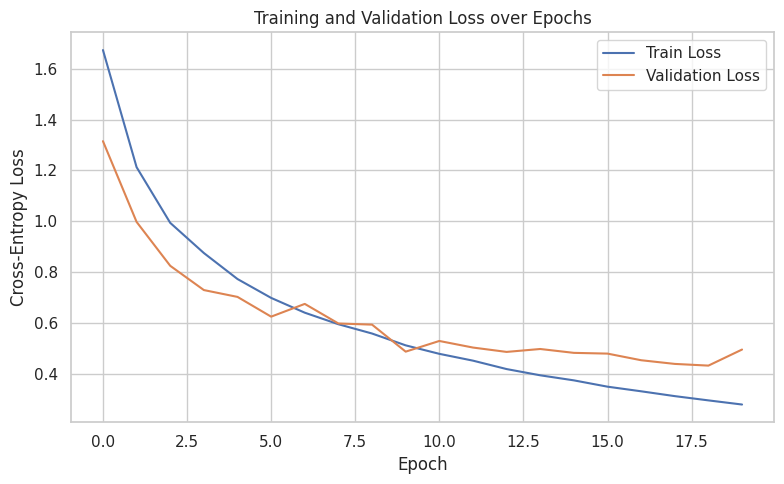

In [8]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.show()


## Evaluation on Test Set and Metrics with Variance

We evaluate the final model on the **test set** and compute:
- Accuracy
- Precision (macro-averaged)
- Recall (macro-averaged)
- F1-score (macro-averaged)
- Matthews Correlation Coefficient (MCC)
- Cohen's kappa

To estimate **variance**, we perform bootstrap resampling on the test predictions.


In [9]:
# Get logits and targets for train and test for later ROC/PR analysis
train_loss_final, train_logits, train_targets = evaluate(model, train_loader, device)
print(f"Final train loss: {train_loss_final:.4f}")

test_loss, test_logits, test_targets = evaluate(model, test_loader, device)
print(f"Test loss: {test_loss:.4f}")

# Convert logits to probabilities and predictions
train_probs = F.softmax(train_logits, dim=1).numpy()
train_y_true = train_targets.numpy()

test_probs = F.softmax(test_logits, dim=1).numpy()
test_y_true = test_targets.numpy()

test_y_pred = np.argmax(test_probs, axis=1)

print('Test set size:', len(test_y_true))


Final train loss: 0.2059
Test loss: 0.5445
Test set size: 10000


In [10]:
def compute_classification_metrics(y_true, y_pred, y_proba, num_classes):
    # macro-averaged precision, recall, f1
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    # Multiclass ROC AUC (macro one-vs-rest)
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    try:
        auc_macro = roc_auc_score(y_true_bin, y_proba, multi_class='ovr', average='macro')
    except ValueError:
        auc_macro = np.nan

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'mcc': mcc,
        'kappa': kappa,
        'auc_macro': auc_macro,
    }


def bootstrap_metrics(y_true, y_pred, y_proba, num_classes, n_bootstrap=50, seed=123):
    rng = np.random.RandomState(seed)
    metrics_list = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        m = compute_classification_metrics(y_true[idx], y_pred[idx], y_proba[idx], num_classes)
        metrics_list.append(m)
    return metrics_list


metrics_boot = bootstrap_metrics(test_y_true, test_y_pred, test_probs, NUM_CLASSES, n_bootstrap=50)

metric_names = ['accuracy', 'precision', 'recall', 'f1', 'mcc', 'kappa', 'auc_macro']

print('Bootstrap mean ± variance of metrics (test set):')
for name in metric_names:
    vals = np.array([m[name] for m in metrics_boot])
    print(f"{name:9s}: mean = {vals.mean():.4f}, var = {vals.var():.6f}")


Bootstrap mean ± variance of metrics (test set):
accuracy : mean = 0.8392, var = 0.000016
precision: mean = 0.8455, var = 0.000015
recall   : mean = 0.8394, var = 0.000015
f1       : mean = 0.8381, var = 0.000016
mcc      : mean = 0.8223, var = 0.000019
kappa    : mean = 0.8213, var = 0.000020
auc_macro: mean = 0.9852, var = 0.000000


## AUC Macro Score Box Plot (Bootstrap)

We visualize the distribution of macro ROC AUC scores from bootstrap samples as a box plot.


/tmp/ipykernel_3956/739028008.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(auc_values, vert=True, labels=['Macro AUC'])


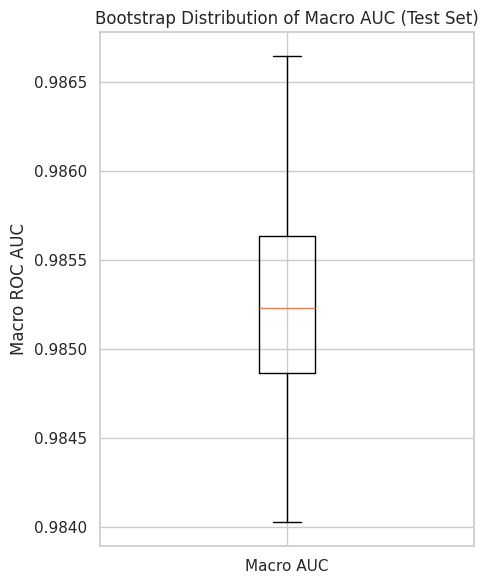

In [11]:
auc_values = np.array([m['auc_macro'] for m in metrics_boot if not np.isnan(m['auc_macro'])])

plt.figure(figsize=(5,6))
plt.boxplot(auc_values, vert=True, labels=['Macro AUC'])
plt.ylabel('Macro ROC AUC')
plt.title('Bootstrap Distribution of Macro AUC (Test Set)')
plt.tight_layout()
plt.show()


## AUROC and AUPRC Curves (Train vs Test)

We compute micro-averaged ROC and Precision–Recall curves for train and test sets:
- **ROC curves** with area-under-curve comparisons between train and test.
- **Precision–Recall curves** with area-under-PR (AUPRC).


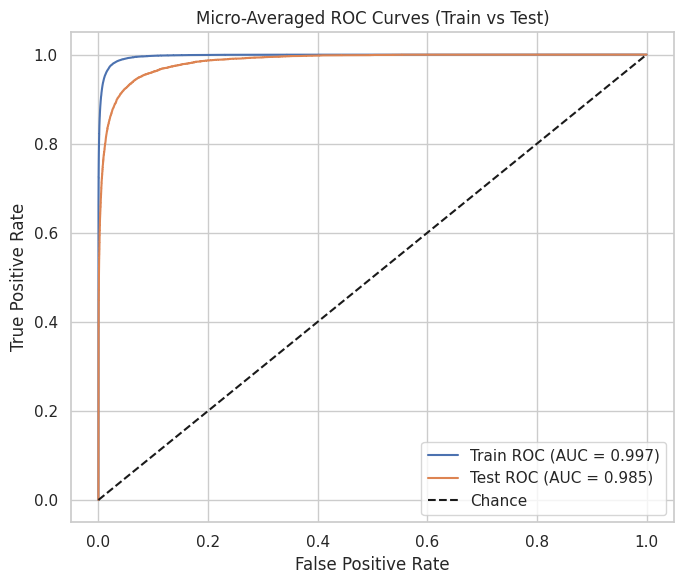

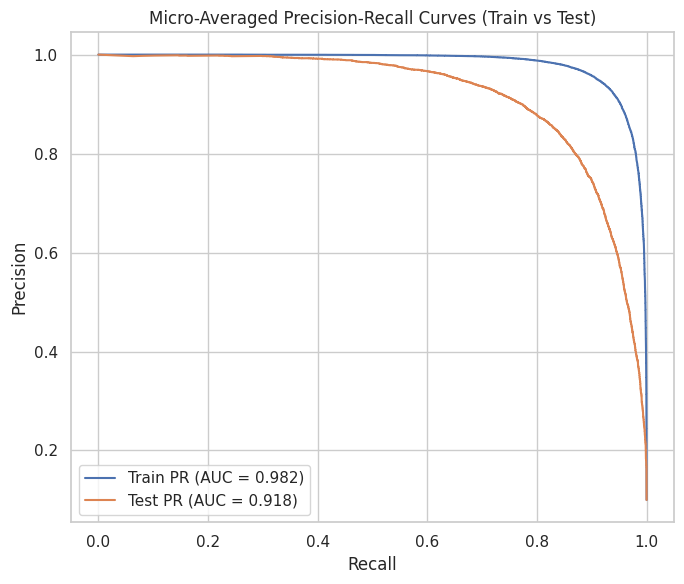

In [12]:
# Binarize labels for micro-averaged curves
y_train_bin = label_binarize(train_y_true, classes=list(range(NUM_CLASSES)))
y_test_bin = label_binarize(test_y_true, classes=list(range(NUM_CLASSES)))

# ROC (micro-average)
train_fpr, train_tpr, _ = roc_curve(y_train_bin.ravel(), train_probs.ravel())
train_roc_auc = auc(train_fpr, train_tpr)

test_fpr, test_tpr, _ = roc_curve(y_test_bin.ravel(), test_probs.ravel())
test_roc_auc = auc(test_fpr, test_tpr)

plt.figure(figsize=(7,6))
plt.plot(train_fpr, train_tpr, label=f'Train ROC (AUC = {train_roc_auc:.3f})')
plt.plot(test_fpr, test_tpr, label=f'Test ROC (AUC = {test_roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-Averaged ROC Curves (Train vs Test)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Precision-Recall (micro-average)
train_prec, train_rec, _ = precision_recall_curve(y_train_bin.ravel(), train_probs.ravel())
train_pr_auc = auc(train_rec, train_prec)

test_prec, test_rec, _ = precision_recall_curve(y_test_bin.ravel(), test_probs.ravel())
test_pr_auc = auc(test_rec, test_prec)

plt.figure(figsize=(7,6))
plt.plot(train_rec, train_prec, label=f'Train PR (AUC = {train_pr_auc:.3f})')
plt.plot(test_rec, test_prec, label=f'Test PR (AUC = {test_pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Micro-Averaged Precision-Recall Curves (Train vs Test)')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


## Confusion Matrix (Test Set)

We plot a normalized confusion matrix to inspect class-wise performance.


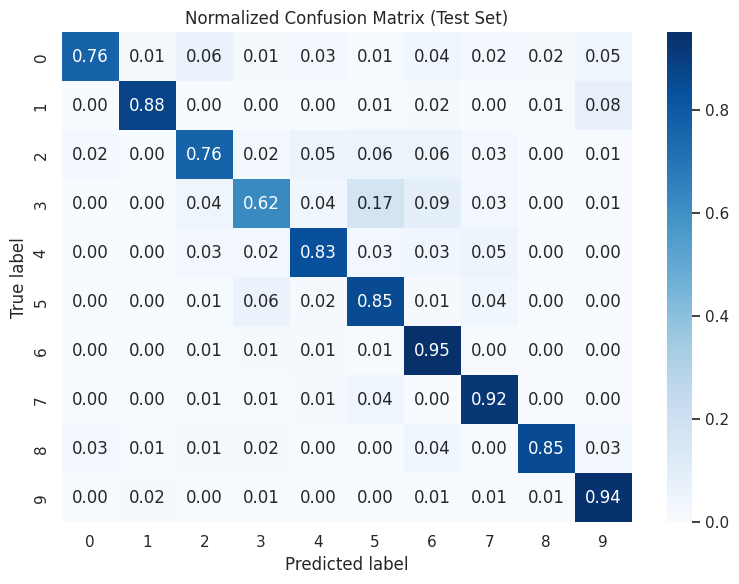

In [13]:
cm = confusion_matrix(test_y_true, test_y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Normalized Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()


## Saliency Maps for Interpretability

We generate **saliency maps** for sample test images:
- For each image, we compute the gradient of the predicted class score with respect to the input pixels.
- We visualize the absolute gradient aggregated across channels as a heatmap, highlighting pixels most influential for the prediction.


In [14]:
def compute_saliency_samples(model, dataset, device, num_samples=5):
    model.eval()
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    images_list = []
    labels_list = []
    preds_list = []
    saliency_list = []

    for idx in indices:
        img, label = dataset[idx]
        img = img.to(device)
        img = img.unsqueeze(0)
        img.requires_grad_(True)

        # Forward
        logits = model(img)
        pred_class = logits.argmax(dim=1).item()
        score = logits[0, pred_class]

        # Backward
        model.zero_grad()
        if img.grad is not None:
            img.grad.zero_()
        score.backward()

        grad = img.grad.detach()[0]  # (C,H,W)
        saliency = grad.abs().max(dim=0)[0].cpu().numpy()  # (H,W)

        images_list.append(img.detach().cpu().numpy()[0])
        labels_list.append(label)
        preds_list.append(pred_class)
        saliency_list.append(saliency)

    return indices, np.array(images_list), np.array(labels_list), np.array(preds_list), np.array(saliency_list)


In [15]:
# Compute saliency on a few test samples

num_saliency_samples = 5
indices_s, imgs_s, labels_s, preds_s, saliencies_s = compute_saliency_samples(model, test_dataset, device, num_samples=num_saliency_samples)
print('Saliency computed for test indices:', indices_s)


Saliency computed for test indices: [6252 4684 1731 4742 4521]


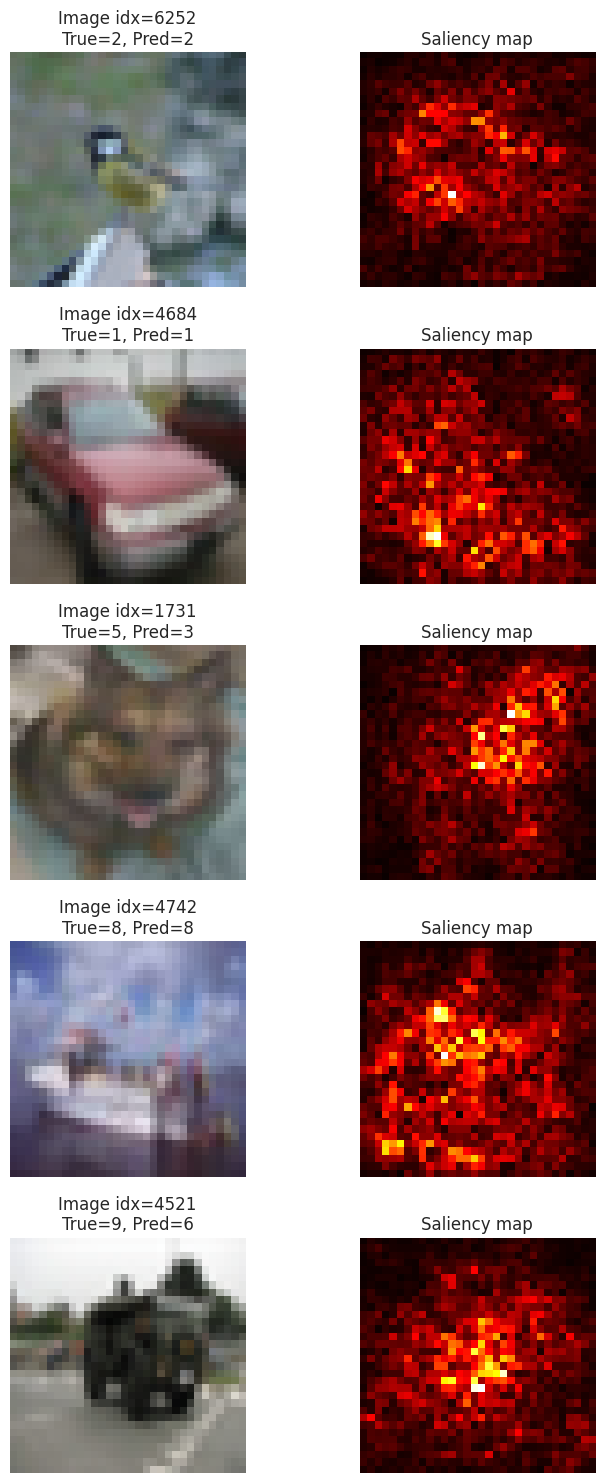

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Plot saliency maps alongside original images (using unnormalized images for display)

# Helper to denormalize CIFAR-10 images for visualization
mean = np.array([0.4914, 0.4822, 0.4465]).reshape(3,1,1)
std = np.array([0.2470, 0.2435, 0.2616]).reshape(3,1,1)

fig, axes = plt.subplots(num_saliency_samples, 2, figsize=(8, 3 * num_saliency_samples))
if num_saliency_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_saliency_samples):
    img = imgs_s[i]
    sal = saliencies_s[i]

    # Denormalize
    img_denorm = (img * std + mean).transpose(1,2,0)
    img_denorm = np.clip(img_denorm, 0, 1)

    ax_img, ax_sal = axes[i]
    ax_img.imshow(img_denorm)
    ax_img.axis('off')
    ax_img.set_title(f'Image idx={indices_s[i]}\nTrue={labels_s[i]}, Pred={preds_s[i]}')

    im = ax_sal.imshow(sal, cmap='hot')
    ax_sal.axis('off')
    ax_sal.set_title('Saliency map')

plt.tight_layout()
plt.show()

This completes the multiclass classification demo with a deep neural network on CIFAR-10, including rich metrics, ROC/PR analysis, confusion matrix, and saliency-based interpretability, all leveraging GPU acceleration when available.